# Homework set 2

Please **submit this Jupyter notebook through Canvas** no later than **Thursday November 14**. **Submit the notebook file with your answers (as .ipynb file) and a pdf printout. The pdf version can be used by the teachers to provide feedback. On canvas there are hints about creating a nice pdf version.**

Before you hand in, please make sure the notebook runs, by running "Restart kernel and run all cells..." from the Kernel menu.

Homework is in **groups of two**, and you are expected to hand in original work. Work that is copied from another group will not be accepted.

# Exercise 0
Write down the names + student ID of the people in your group.

Run the following cell to import NumPy, Matplotlib and some other functions.

In [2]:
import math
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

---

# Very short introduction to Matplotlib

`matplotlib` is a useful package for visualizing data using Python. Run the first cell below to plot $\sqrt{x}, x, x^2, x^3$ for $x \in [1, 10]$.

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


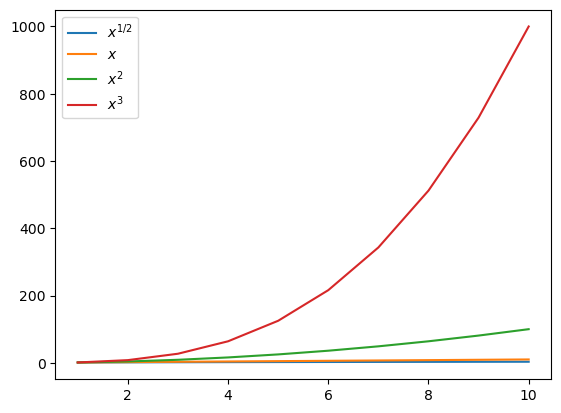

In [4]:
x = np.linspace(1, 10, 10)  # 10 points evenly between 1 and 10.
print(x)
plt.plot(x, x**0.5, label=r"$x^{1/2}$")
plt.plot(x, x**1, label=r"$x$")
plt.plot(x, x**2, label=r"$x^2$")
plt.plot(x, x**3, label=r"$x^3$")
plt.legend()
plt.show()

When visualizing functions where $y$ has many different orders of magnitude, a logarithmic scale is useful:

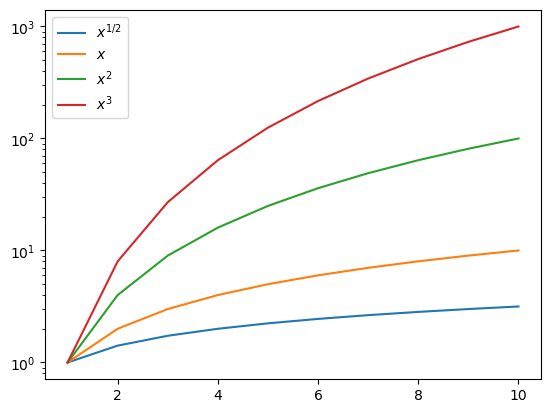

In [5]:
x = np.linspace(1, 10, 10)
plt.semilogy(x, x**0.5, label=r"$x^{1/2}$")
plt.semilogy(x, x**1, label=r"$x$")
plt.semilogy(x, x**2, label=r"$x^2$")
plt.semilogy(x, x**3, label=r"$x^3$")
plt.legend()
plt.show()

When also the $x$-axis contains many orders of magnitude, a log-log plot is most useful:

[1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07 1.e+08 1.e+09 1.e+10]


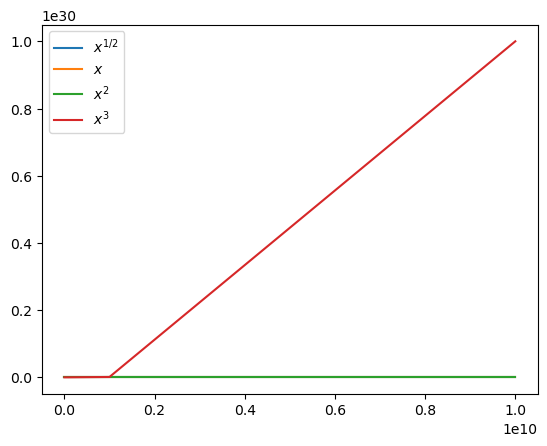

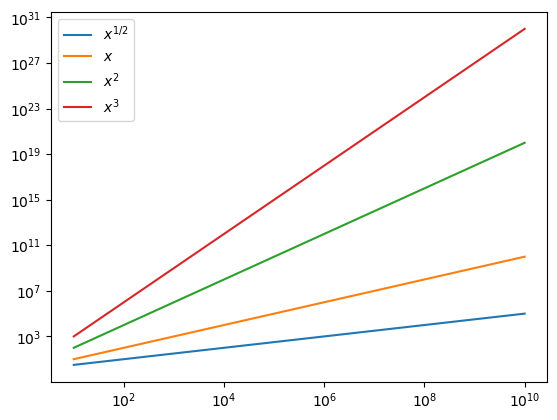

In [6]:
x = np.logspace(1, 10, 10, base=10)  # 10 points evenly between 10^1 and 10^10.
print(x)

plt.plot(x, x**0.5, label=r"$x^{1/2}$")
plt.plot(x, x**1, label=r"$x$")
plt.plot(x, x**2, label=r"$x^2$")
plt.plot(x, x**3, label=r"$x^3$")
plt.legend()
plt.show()

plt.loglog(x, x**0.5, label=r"$x^{1/2}$")
plt.loglog(x, x**1, label=r"$x$")
plt.loglog(x, x**2, label=r"$x^2$")
plt.loglog(x, x**3, label=r"$x^3$")
plt.legend()
plt.show()

## Plots of arbitrary curves in the $(x,y)$ plane

So far, in all our plots, $y$ was a function of $x$. But this is not the only possibility. One can draw arbitrary curves in the $(x,y)$ plane. Next are two examples

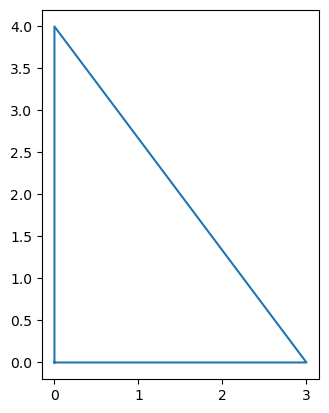

In [7]:
# plot a triangle
x = [0, 3, 0, 0]
y = [0, 0, 4, 0]
plt.plot(x,y)
# set aspect ratio to one
plt.gca().set_aspect('equal')

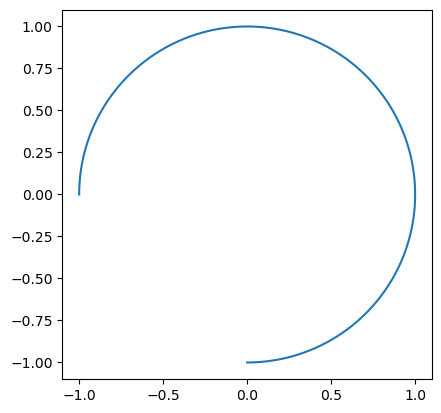

In [8]:
# we plot three quarters of a circle from (0,-1) going counter clockwise to (-1,0)
t = np.linspace(-0.5*np.pi, np.pi, 271)
x = np.cos(t)    
y = np.sin(t)
plt.plot(x,y)
# set the aspectratio to 1 so that it truely looks like a circle
plt.gca().set_aspect('equal')

---

# Exercise 1

Show that the Gram–Schmidt orthogonalization of an $m \times m$ matrix requires approximately $m^3$ multiplications and $m^3$ additions.


To estimate the number of operations required for Gram-Schmidt orthogonalization on an $m \times m$ matrix $A$, we break down the steps involved in processing each column vector in $A$:
##### Multiplication
1. Projection Calculation:  
   For each vector $a_i$, we compute the projections onto the previously computed orthogonal vectors. The projection involves the following operations:
   Top dot product: The inner product $(u_k, v_j)$ requires $m$ multiplications and $m - 1$ additions.
   Bottom dot product: The inner product $(u_k, u_k)$ for normalization also requires $m$ multiplications and $m - 1$ additions.
2. Division:  
   Each projection includes a division by the norm $(u_k, u_k)$, which requires 1 division.
3. Scalar Multiplication:  
   Each projection calculation $\frac{(u_k, v_j)}{(u_k, u_k)}$ requires multiplying this scalar by the vector $u_k$, which involves $m$ multiplications.


For each projection, we have:
   $m$ multiplications for the top dot product, $m$ multiplications for the bottom dot product, $m$ multiplications for the scalar multiplication,$1$ division.

So, the total number of multiplications per projection is:
$[3m + 1]$


Since we perform $i - 1$ projections for the $i$-th vector in the matrix (the first vector has no projection), we sum these operations across all vectors. For the entire matrix, this totals approximately:

$\sum_{i=2}^m \left( (3m + 1)(i - 1) \right) \approx m^3$

##### Addition

For each projection, we have $m-1$ additions for the top dot product , $m-1$ additions for the bottom dot product, and $m$ subtractions for orthogonalizing 

The total number of additions for each projection is:
$$(m - 1)(i - 1) + (m - 1)(i - 1) + m(i - 1) = (k - 1)(3m - 2)$$

Summing over all $m$ steps:

$$\text{Total additions} = \sum_{i=2}^{m} (3m - 2)(i - 1) = (3m - 2) \cdot \sum_{i=2}^{m} (i - 1) = (3m - 2) \cdot \frac{m(m-1)}{2} = \frac{3m^3 - 5m^2 + 2m}{2}.$$

This simplifies to:
$$\frac{3m^3 - 5m^2 + 2m}{2} \approx {m^3}$$




-----
# Exercise 2
We want to reconstruct a function $s(t)$ (also called the signal in this exercise), $t \in [0,1]$, from data given by
$$d(t) = \int_0^1 s(t) \, dt + \text{noise}.$$
We assume the data is given at $n$ equally space time points $t_j = j h$, $h = \frac{1}{n}$, $j=1,2, \ldots, n$. The data is therefore a vector $d = [d_1, \ldots, d_n]$, where $d_j$ denotes the value at $t_j$. 
The signal $s$ is to be reconstructed at time points 
$t_{j-1/2} = (j-1/2)h$ for $j = 1,2, \ldots, n$. It is described by a vector $s = [s_1, \ldots, s_n]$ with $s_j$ the value at $t_{j-1/2}$.
Numerical integration is described in Chapter 8 of the book by Heath. Using the composite midpoint rule, the vectors $s$ and $d$ are related by
$$d = A \cdot s + \text{noise}$$
where
$$A = \begin{bmatrix} 
h & 0 & 0 & \ldots & 0 \\
h & h & 0 & \ldots & 0 \\
h & h & h & \ddots &  \vdots \\
\vdots & \vdots & \ddots & \ddots & 0 \\
h & h & \ldots & h  & h 
\end{bmatrix}.$$


## (a)
As a test signal we take
$$s_{\rm true}(t) = \left\{
\begin{array}{ll} 
1 & \text{if $0.05 \le |t-1/2|<0.15$}\\
0.7 & \text{if $|t-1/2|<0.05$}\\
0 & \text{otherwise} \end{array} 
\right. .$$ 
Generate data $d_0$ without noise and data $d_\epsilon$ with noise, where the noise is normally distributed, with mean zero and standard deviation $\epsilon = 0.005$.
Take for example $n=100$. Plot the data.

In [3]:
# YOUR CODE HERE
import numpy as np 

n=100
h=1/n
timepoints=[j*h for j in range(n)]
def piece_wise(t):
    a=abs(t-0.5)
    if(a<0.05):
        return 0.7
    elif(a<0.15 and 0.05<=a):
        return 1
    else:
        return 0

def true_signal():
    s=[piece_wise((j-0.5)*h) for j in range(n) ]
    s=np.array(s)
    return s
def construct_matrix(A):
    for i in range(n):
        for j in range(n):
            if(i>=j):
                A[i][j]=h
    return A
A=np.zeros(shape=(n,n))
A=construct_matrix(A)
print(A.shape)

s_true=true_signal()
print(s_true.shape)
import numpy as np 
d_0= A @ s_true

print(d_0.shape)
print(d_0)

(100, 100)
(100,)
(100,)
[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.01  0.02  0.03  0.04  0.05  0.06  0.07  0.08  0.09  0.1   0.107 0.114
 0.121 0.128 0.135 0.142 0.149 0.156 0.163 0.17  0.18  0.19  0.2   0.21
 0.22  0.23  0.24  0.25  0.26  0.27  0.27  0.27  0.27  0.27  0.27  0.27
 0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27
 0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27  0.27
 0.27  0.27  0.27  0.27 ]


In [4]:
mu =0
sigma=0.005
d_epsilon=[]
noise = np.random.normal(mu, sigma, n)
for i in range (len(noise)):
    d_epsilon.append(d_0[i]+noise[i])
d_epsilon=np.array(d_epsilon)
print(d_epsilon.shape)

(100,)


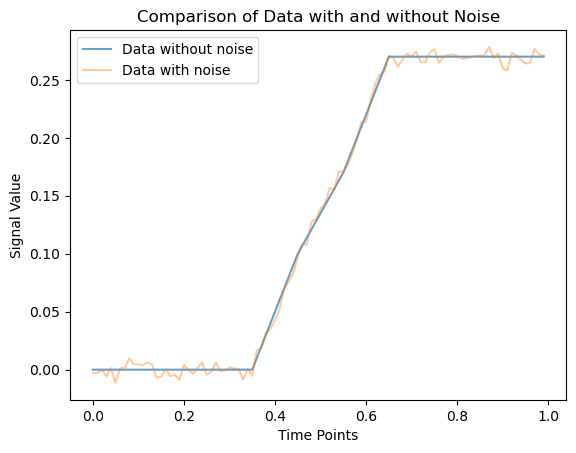

In [5]:
import matplotlib.pyplot as plt 
plt.plot(timepoints, d_0, alpha =0.7,label="Data without noise")
plt.plot(timepoints, d_epsilon, alpha=0.4, label="Data with noise")
plt.legend()
plt.xlabel('Time Points')   
plt.ylabel('Signal Value') 
plt.title('Comparison of Data with and without Noise')  
plt.show()

## (b)
Try to determine $s$ from $d_0$ by inverting the matrix $A$, ignoring the noise term.
Do the same with $d_\epsilon$ instead of $d_0$. Plot the results. What do you observe about the errors in the inversion?

You may use a library routine for matrix inversion/solving a linear system.

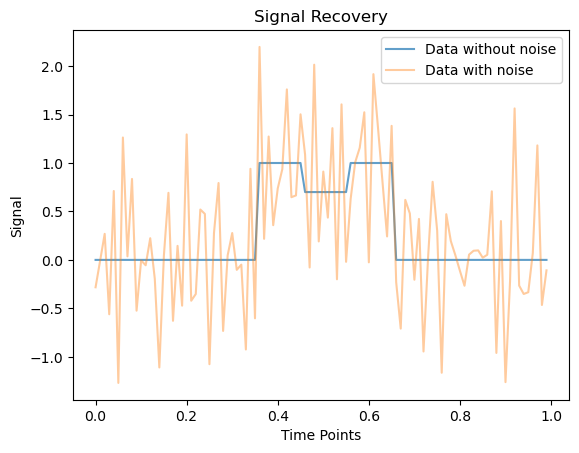

In [6]:
# YOUR CODE HERE
from numpy.linalg import inv 
A_inv=inv(A)
s_d0=A_inv @ d_0
s_depsilon=A_inv @ d_epsilon
plt.plot(timepoints, s_d0, alpha =0.7,label="Data without noise")
plt.plot(timepoints, s_depsilon, alpha=0.4, label="Data with noise")
plt.legend()
plt.xlabel('Time Points')  
plt.ylabel('Signal')      
plt.title('Signal Recovery')  
plt.show()
plt.show()


## (c)
One way to address the issue just observed is by truncated SVD regularization. Suppose $A = U \Sigma V^T$ is the singular value decomposition of $A$. 

Express the inverse $A^{-1}$ in terms of $U, V$ and $\Sigma$, or in terms of $U$, $V$ and the singular values.

Let $k$ be some integer less or equal than $n$. Denote by $B_k$ the matrix that is obtained from $A$ by setting the smallest $n-k$ singular values to zero (and keeping $U$, $V$ and the first $k$ singular values the same). 

In truncated SVD regularization, an estimate for $s$ is obtained by applying the pseudoinverse $B_k^{+}$ to the data (instead of the true inverse $A^{-1}$) (see section 3.6 of Heath). Try truncated SVD regularization for various values of $k$. Show that for certain values of $k$ the result obtained by truncated SVD regularization is a "better" approximation of the true signal than the result obtained by the true inverse $A^{-1}$.
Note that better can mean different things, it can mean "visually better" or "quantitatively better" in some norm to be specified, try to be precise in what you write down.

What happens if you choose $k$ too small?

You may use library routines to compute the SVD.

If the value of $k$ is too small many of the singular values maybe discarded loosing information and may lead to underfitting the model .However if the value of $k$ is too large many singular values maybe retained corresponding to the noise and the model may overfit to the given data at hand and captures more of the noise than the true signal.

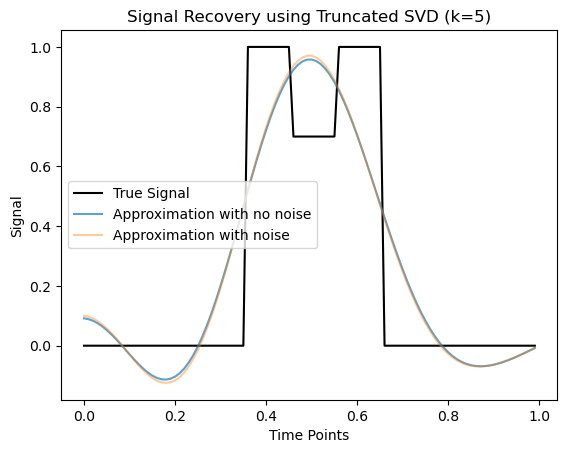

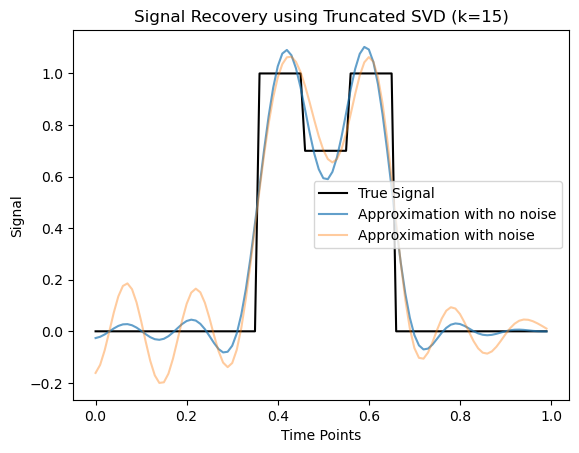

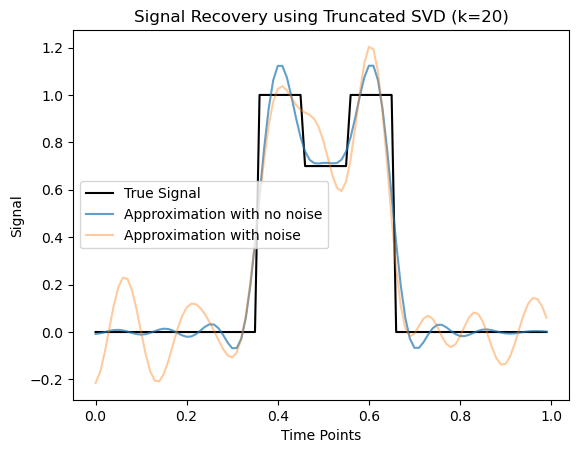

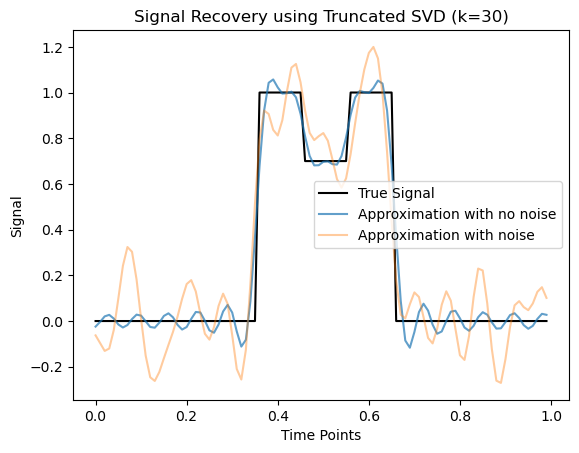

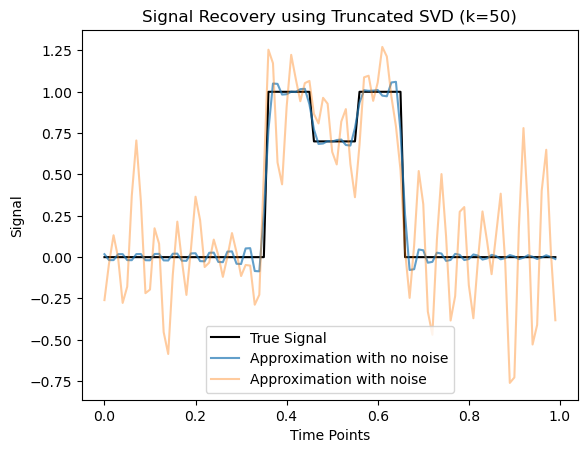

In [13]:
# YOUR CODE HERE
from numpy.linalg import svd

def truncated(U, Sigma, V, k):
    diagonal_elements=[]
    for i, s in enumerate(Sigma):
        if i < k:
            diagonal_elements.append(1 / s)
        else:
            diagonal_elements.append(0)
    Sigma_trunc_inv = np.diag(diagonal_elements)
    trunc=V @ Sigma_trunc_inv @ U.T
    return trunc

U, Sigma, VT = svd(A)
V = VT.T
k_values=[5, 15, 20, 30, 50]

for k in k_values: 
    B_k_plus = truncated(U, Sigma, V, k)
    s_d0_approx = B_k_plus @ d_0
    s_depsilon_approx = B_k_plus @ d_epsilon

    plt.plot(timepoints, s_true, label="True Signal", color="black", linestyle="-")

    plt.plot(timepoints, s_d0_approx, alpha=0.7, label=f"Approximation with no noise")
    plt.plot(timepoints, s_depsilon_approx, alpha=0.4, label=f"Approximation with noise")
    plt.xlabel('Time Points')
    plt.ylabel('Signal')
    plt.title(f'Signal Recovery using Truncated SVD (k={k})')
    plt.legend()
    plt.show()


## (d)

Make a plot of the singular values of $A$. Explain your findings in (b) and (c). Part of your explanation should refer to the plot.

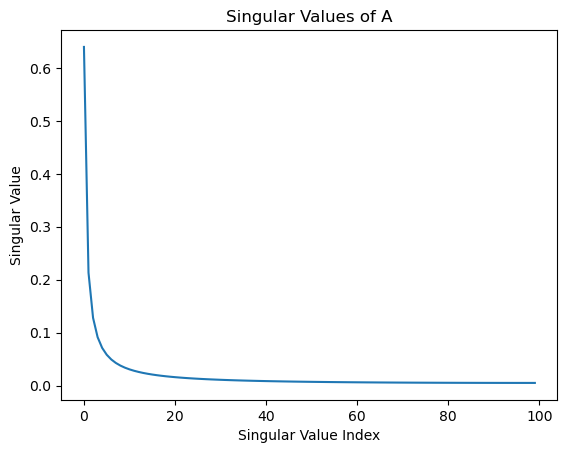

In [9]:
_, Sigma, _= svd(A)
plt.plot(Sigma)
plt.xlabel("Singular Value Index")
plt.ylabel('Singular Value')
plt.title('Singular Values of A')
plt.show()

*Text part of your answer here*